<a href="https://colab.research.google.com/github/ramsaher/DEVF_Master_Ciencias_de_Datos/blob/main/Leccion_08_Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_Estad%C3%ADstico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

## **Proyecto: Análisis Estadístico de Accidentes de Auto**  
## Dataset: Accidentes de Auto (`car_crashes`)

Imaginemos que somos un analista de datos contratado por una aseguradora de autos. El cliente nos da una tabla con información de accidentes de 50 estados de EE.UU. y nos pide que:

1. **Entendamos el dataset**: ¿Cuántos datos hay? ¿Qué columnas tiene? ¿Hay datos faltantes?
2. **Hagamos un resumen estadístico**: Promedios, máximos, mínimos, qué tan dispersos están los datos.
3. **Lo visualicemos**: Graficas para ver patrones a simple vista.
4. **Predecir comportamientos**: Usar regresión lineal para entender si una variable afecta a otra.

 📌 **Objetivo**
Entender qué factores se relacionan con los accidentes y construir un modelo sencillo para predecir el número de accidentes a partir de alguna otra variable.



## 📦 **BLOQUE 1: Instalación de librerías y carga de datos**

In [ ]:
# IMPORTAR LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuramos el estilo de los gráficos para que se vean profesionales

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)  # Tamaño estándar de figuras

# 📌 warnings: evitamos advertencias innecesarias

import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente para todas las gráficas
# 'whitegrid' = fondo blanco con cuadrícula

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Las gráficas se muestran dentro del notebook

%matplotlib inline



In [ ]:
# Cargamos el dataset de accidentes desde seaborn
df = sns.load_dataset('car_crashes')

## 🔍 **BLOQUE 2: Exploración Inicial del Dataset**

### ¿Por qué explorar primero?
Antes de analizar cualquier dataset, necesitamos **conocerlo** como a un nuevo compañero de trabajo:
- ¿Cuántas filas y columnas tiene?
- ¿Qué tipo de información contiene cada columna?
- ¿Hay datos faltantes (vacíos)?
- ¿Qué rango tienen los valores?

### 📋 Diccionario del Dataset `car_crashes`

| Columna | Significado |
|---------|-------------|
| `total` | Total de accidentes mortales por cada millón de millas conducidas |
| `speeding` | Accidentes donde el exceso de velocidad fue factor |
| `alcohol` | Accidentes donde el alcohol fue factor |
| `not_distracted` | Accidentes donde el conductor NO estaba distraído |
| `no_previous` | Accidentes de conductores sin historial previo |
| `ins_premium` | Prima de seguro promedio (en dólares) |
| `ins_losses` | Pérdidas de la aseguradora por choques (en dólares) |
| `abbrev` | Abreviatura del estado de EE.UU. |

In [ ]:
# Mostramos las primeras 8 filas para ver cómo esta el dataset

print("Primeras 8 filas del dataset:")
df.head()

Primeras 8 filas del dataset:


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


**.info() es como el currículum vitae del dataset:**
 - Cuántas filas tiene
 - Nombre de cada columna
 - Cuántos valores NO nulos (no vacíos) tiene
 - Tipo de dato de cada columna:

In [ ]:

print(' Información técnica del dataset:')
print('-' * 50)
df.info()

 Información técnica del dataset:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   total           51 non-null     float64
 1   speeding        51 non-null     float64
 2   alcohol         51 non-null     float64
 3   not_distracted  51 non-null     float64
 4   no_previous     51 non-null     float64
 5   ins_premium     51 non-null     float64
 6   ins_losses      51 non-null     float64
 7   abbrev          51 non-null     object 
dtypes: float64(7), object(1)
memory usage: 3.3+ KB


In [ ]:
# DIMENSIONES Y TIPOS DE DATOS

# .shape nos da una tupla (filas, columnas)
filas, columnas = df.shape

# Separamos columnas numéricas de categóricas (texto)

cols_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cols_texto     = df.select_dtypes(include=['object']).columns.tolist()

print('Dimensiones del Dataset')
print(f'   Filas     : {filas} (cada fila = un estado de EE.UU.)')
print(f'   Columnas  : {columnas}')
print()
print(f' Columnas numéricas ({len(cols_numericas)}):')
for col in cols_numericas:
    print(f'   - {col}')
print()
print(f' Columnas de texto ({len(cols_texto)}):')
for col in cols_texto:
    print(f'   - {col}')

Dimensiones del Dataset
   Filas     : 51 (cada fila = un estado de EE.UU.)
   Columnas  : 8

 Columnas numéricas (7):
   - total
   - speeding
   - alcohol
   - not_distracted
   - no_previous
   - ins_premium
   - ins_losses

 Columnas de texto (1):
   - abbrev


In [ ]:

# ¿Qué columnas tenemos?
print("\n Nombres de las columnas ")
print(df.columns.tolist())


 Nombres de las columnas 
['total', 'speeding', 'alcohol', 'not_distracted', 'no_previous', 'ins_premium', 'ins_losses', 'abbrev']


**Valores faltantes (muy importante)**

- Los valores nulos son celdas vacías: datos que faltan.
- Pueden arruinar un análisis si no los detectamos.
-.isnull() → crea una tabla de True/False (True = está vacío)
- .sum()    → suma los True de cada columna (True cuenta como 1)

 El resultado nos dice cuántos valores faltan por columna.

In [ ]:
# Verificar valores faltantes

nulos = df.isnull().sum()

print('Valores nulos por columna:')
print('-' * 35)
print(nulos)
print('-' * 35)

if nulos.sum() == 0:
    print('\n ¡Excelente! El dataset está completo, sin valores faltantes.')
else:
    print(f'\n Se encontraron {nulos.sum()} valores nulos que requieren atención.')

Valores nulos por columna:
-----------------------------------
total             0
speeding          0
alcohol           0
not_distracted    0
no_previous       0
ins_premium       0
ins_losses        0
abbrev            0
dtype: int64
-----------------------------------

 ¡Excelente! El dataset está completo, sin valores faltantes.


## 📊 **BLOQUE 3: Análisis Descriptivo**

### ***¿Qué es el Análisis Descriptivo?***
Es como hacer un **resumen ejecutivo** de los datos. Usamos números para responder preguntas básicas:

| Pregunta | Estadístico |
|----------|-------------|
| ¿Cuál es el valor típico? | Media (promedio) |
| ¿Cuál es el valor del centro? | Mediana |
| ¿Qué tanto varían los datos? | Desviación estándar |
| ¿Cuáles son los extremos? | Mínimo y Máximo |
| ¿Cómo se distribuye el 50% central? | Cuartiles Q1 y Q3 |

###  Conceptos Clave:

**Media (promedio)**: Suma todos los valores y los divide entre el número de datos.
> Ejemplo: Si 3 estados tienen 5, 10 y 15 accidentes → Media = (5+10+15)/3 = **10**

**Mediana**: El valor del **centro** es cuando ordenamos los datos. Es más robusta que la media porque no se afecta por valores extremos.

**Desviación Estándar**: Mide qué tan **dispersos** o **juntos** están los datos alrededor de la media.

**Cuartiles**: Dividen los datos en 4 partes iguales:
- Q1 (25%): el 25% de los datos está por debajo de este valor
- Q2 (50%): la mediana
- Q3 (75%): el 75% de los datos está por debajo de este valor

 **.describe() es la función más poderosa para análisis descriptivo.**
Con UN solo comando genera para cada columna numérica:
-   count  = número de datos (sin contar nulos)
-  mean   = media (promedio aritmético)
-  std    = desviación estándar
-  min    = valor mínimo
-  25%    = primer cuartil (Q1)
- 50%    = mediana (Q2)
- 75%    = tercer cuartil (Q3)
-  max    = valor máximo

In [ ]:

# RESUMEN ESTADÍSTICO GENERAL

# .round(2) redondea a 2 decimales para mayor legibilidad
# .T transpone la tabla → más fácil de leer por variable

print('📊 Resumen Estadístico Completo')
print('=' * 60)
resumen = df.describe().round(2)
resumen.T

📊 Resumen Estadístico Completo


,count,mean,std,min,25%,50%,75%,max
total,51.0,15.79,4.12,5.90,12.75,15.60,18.50,23.90
speeding,51.0,5.00,2.02,1.79,3.77,4.61,6.44,9.45
alcohol,51.0,4.89,1.73,1.59,3.89,4.55,5.60,10.04
not_distracted,51.0,13.57,4.51,1.76,10.48,13.86,16.14,23.66
no_previous,51.0,14.00,3.76,5.90,11.35,13.78,16.76,21.28
ins_premium,51.0,886.96,178.30,641.96,768.43,858.97,1007.94,1301.52
ins_losses,51.0,134.49,24.84,82.75,114.64,136.05,151.87,194.78


 **El Coeficiente de Variación (CV) mide la dispersión relativa:**
   - CV = (desviación estándar / media) * 100*
   - CV < 15%  → datos homogéneos (pocos están muy alejados del promedio)*
   - CV 15-30% → dispersión moderada*
   - CV > 30%  → datos muy dispersos (alta variabilidad)*

In [ ]:
# ANÁLISIS DETALLADO POR COLUMNA

df_num = df.select_dtypes(include=['float64', 'int64'])

print('Análisis Detallado por Variable')
print('=' * 65)
print(f'{"Variable":<20} {"Media":>8} {"Mediana":>8} {"Std":>8} {"Rango":>8} {"CV %":>7}')
print('-' * 65)

for col in df_num.columns:
    media   = df_num[col].mean()
    mediana = df_num[col].median()
    std     = df_num[col].std()
    rango   = df_num[col].max() - df_num[col].min()
    cv      = (std / media) * 100 if media != 0 else 0
    print(f'{col:<20} {media:>8.2f} {mediana:>8.2f} {std:>8.2f} {rango:>8.2f} {cv:>6.1f}%')

print('=' * 65)
print('\n CV = Coeficiente de Variación')
print('   CV < 15%  → datos muy homogéneos')
print('   CV 15-30% → dispersión moderada')
print('   CV > 30%  → datos muy dispersos')

Análisis Detallado por Variable
Variable                Media  Mediana      Std    Rango    CV %
-----------------------------------------------------------------
total                   15.79    15.60     4.12    18.00   26.1%
speeding                 5.00     4.61     2.02     7.66   40.4%
alcohol                  4.89     4.55     1.73     8.45   35.4%
not_distracted          13.57    13.86     4.51    21.90   33.2%
no_previous             14.00    13.78     3.76    15.38   26.9%
ins_premium            886.96   858.97   178.30   659.56   20.1%
ins_losses             134.49   136.05    24.84   112.03   18.5%

 CV = Coeficiente de Variación
   CV < 15%  → datos muy homogéneos
   CV 15-30% → dispersión moderada
   CV > 30%  → datos muy dispersos


 **Asimetría (Skewness):** indica si los datos están jalados hacia un lado.
   Skewness ≈ 0  → distribución simétrica (perfecta campana)
   Skewness > 0  → cola larga a la DERECHA (pocos valores muy altos)
   Skewness < 0  → cola larga a la IZQUIERDA (pocos valores muy bajos)

 **Curtosis (Kurtosis):** si los datos tienen "picos muy altos" o "colas muy gordas.
   Kurtosis ≈ 0  → distribución normal estándar
   Kurtosis > 0  → muy puntiaguda (datos concentrados al centro)
   Kurtosis < 0  → muy plana (datos más dispersos)

**Tabla Resumen Rápida**

| Concepto | Mide        |  Valor típico    |Interpretación fácil   |
|----------|--------------|-------------------|-----------------------|
| Asimetría| Inclinación  |0 a ±3          |+ = cola derecha larga ,(- = cola izquierda larga)|
| Curtosis | Pico/Colas   |3 (o exceso 0)  |>3 = pico alto, colas delgadas,( <3 = piso plano, colas gordas)
                        




In [ ]:
# ASIMETRÍA Y CURTOSIS

asimetria = df_num.skew().round(3)
curtosis  = df_num.kurt().round(3)

forma = pd.DataFrame({
    'Asimetría (Skewness)': asimetria,
    'Curtosis (Kurtosis)':  curtosis
})

print('Forma de las Distribuciones')
print('=' * 50)
print(forma)
print()
print('Interpretación de Asimetría:')
for col in df_num.columns:
    sk = asimetria[col]
    if abs(sk) < 0.5:
        tipo = 'Aproximadamente simétrica'
    elif sk > 0.5:
        tipo = 'Sesgada a la derecha (cola de valores altos)'
    else:
        tipo = 'Sesgada a la izquierda (cola de valores bajos)'
    print(f'   {col}: {sk} → {tipo}')

Forma de las Distribuciones
                Asimetría (Skewness)  Curtosis (Kurtosis)
total                          0.042               -0.343
speeding                       0.430               -0.531
alcohol                        1.133                2.082
not_distracted                 0.017                0.363
no_previous                   -0.066               -0.611
ins_premium                    0.779               -0.230
ins_losses                     0.164               -0.005

Interpretación de Asimetría:
   total: 0.042 → Aproximadamente simétrica
   speeding: 0.43 → Aproximadamente simétrica
   alcohol: 1.133 → Sesgada a la derecha (cola de valores altos)
   not_distracted: 0.017 → Aproximadamente simétrica
   no_previous: -0.066 → Aproximadamente simétrica
   ins_premium: 0.779 → Sesgada a la derecha (cola de valores altos)
   ins_losses: 0.164 → Aproximadamente simétrica


## 📈 **BLOQUE 4: Visualización Exploratoria**

### **¿Por qué visualizar?**
Los números son importantes, pero una imagen dice más que mil números. Las gráficas nos permiten:
- Detectar patrones que los números no muestran claramente
- Identificar valores atípicos (outliers) a simple vista
- Ver correlaciones entre variables

### Tipos de gráficas que usaremos:

| Gráfica | ¿Para qué sirve? |
|---------|------------------|
| **Histograma** | Ver cómo se distribuyen los valores de una variable |
| **Boxplot** | Ver el rango, mediana y valores atípicos |
| **Heatmap** | Ver correlaciones entre todas las variables a la vez |
| **Scatter plot** | Ver la relación entre 2 variables |
| **Pairplot** | Matriz completa de scatter plots y distribuciones |


#  **HISTOGRAMAS**
 - Un histograma divide los valores en cajitas (bins) y cuenta
 - cuántos datos caen en cada cajita.
 - La altura de cada barra = cuántos estados tienen ese rango de valor.
 - Si la forma es una campana → distribución normal (idealmente simétrica)

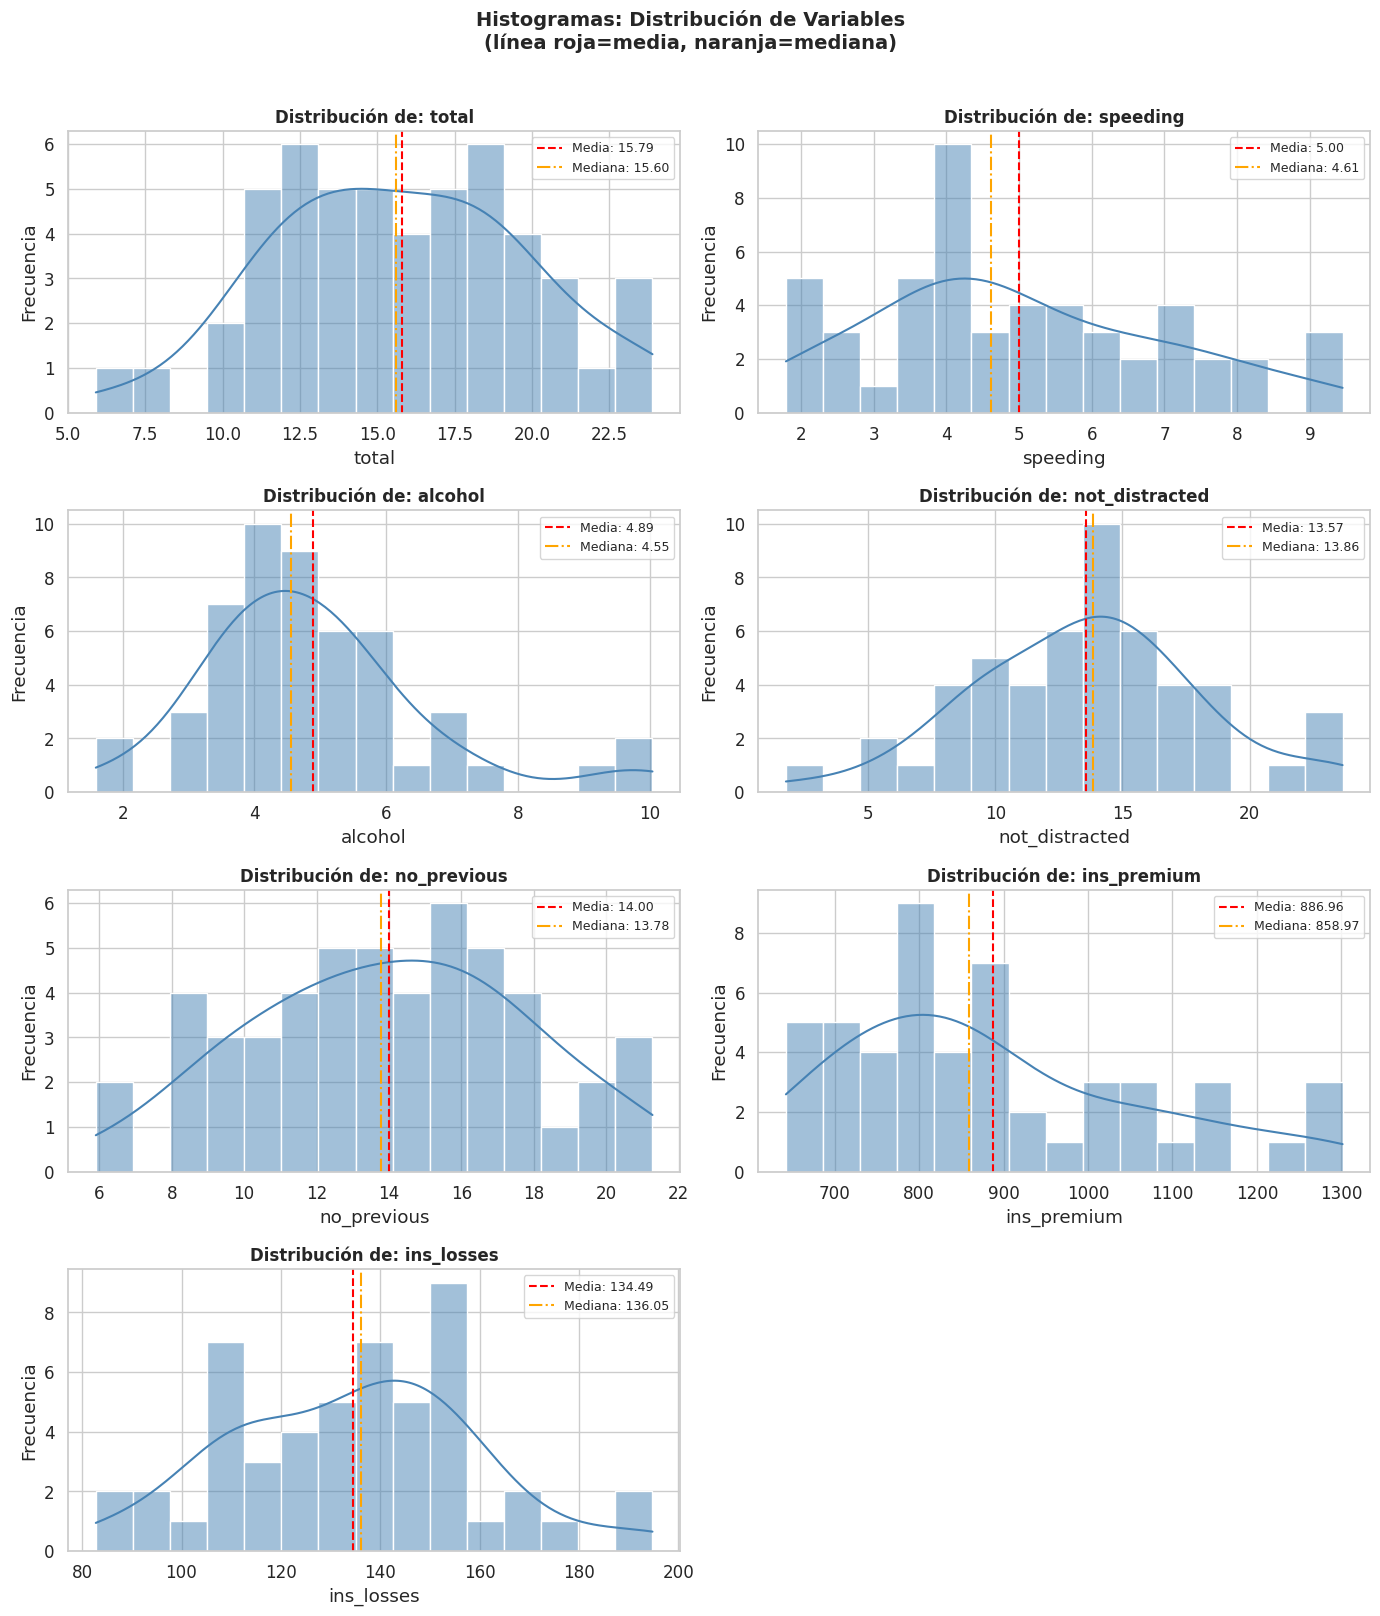


💡 Cómo leer esta gráfica:
   Si rojo (media) ≈ naranja (mediana) → distribución simétrica
   Si rojo > naranja → hay valores muy altos jalando la media
   La curva KDE muestra la forma general de los datos


In [ ]:
# HISTOGRAMAS CON TODAS LAS VARIABLES NUMÉRICAS

variables_num = df.select_dtypes(include=['float64', 'int64']).columns
n_vars = len(variables_num)
n_cols = 2
n_rows = (n_vars + 1) // n_cols  # división entera: sin decimales

# fig, axes: figura con múltiples subgráficas
# figsize=(14, 16): ancho=14, alto=16 pulgadas

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 16))
axes = axes.flatten()  # Convertimos grilla 2D en lista 1D para iterar

for i, col in enumerate(variables_num):
    ax = axes[i]

    # histplot: dibuja el histograma
    # kde=True → también dibuja la curva de densidad suavizada (KDE)
    # La curva KDE es la forma suavizada del histograma

    sns.histplot(data=df, x=col, bins=15, kde=True, color='steelblue', ax=ax)

    # Líneas verticales: media (roja) y mediana (naranja)
    # axvline = línea vertical en un valor específico del eje X

    media   = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media,   color='red',    linestyle='--',  linewidth=1.5, label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='orange', linestyle='-.',  linewidth=1.5, label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribución de: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

if n_vars % 2 != 0:
    axes[-1].set_visible(False)

fig.suptitle('Histogramas: Distribución de Variables\n(línea roja=media, naranja=mediana)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n Cómo interpretar esta gráfica:')
print('   Si rojo (media) ≈ naranja (mediana) → distribución simétrica')
print('   Si rojo > naranja → hay valores muy altos jalando la media')
print('   La curva KDE muestra la forma general de los datos')

# **BOXPLOTS (DIAGRAMAS DE CAJA)**

El Boxplot resume 5 números clave visualmente:

-   Línea superior del bigote = Máximo (o Q3 + 1.5*IQR)
-   Borde superior de la caja = Q3 (75% de los datos abajo)
-   Línea dentro de la caja   = Mediana (50%)
-   Borde inferior de la caja = Q1 (25%)
-   Línea inferior del bigote = Mínimo (o Q1 - 1.5*IQR)
-   Puntos fuera de bigotes   = OUTLIERS (valores atípicos)

 IQR = Rango Intercuartílico = Q3 - Q1 (el 50% central de los datos)

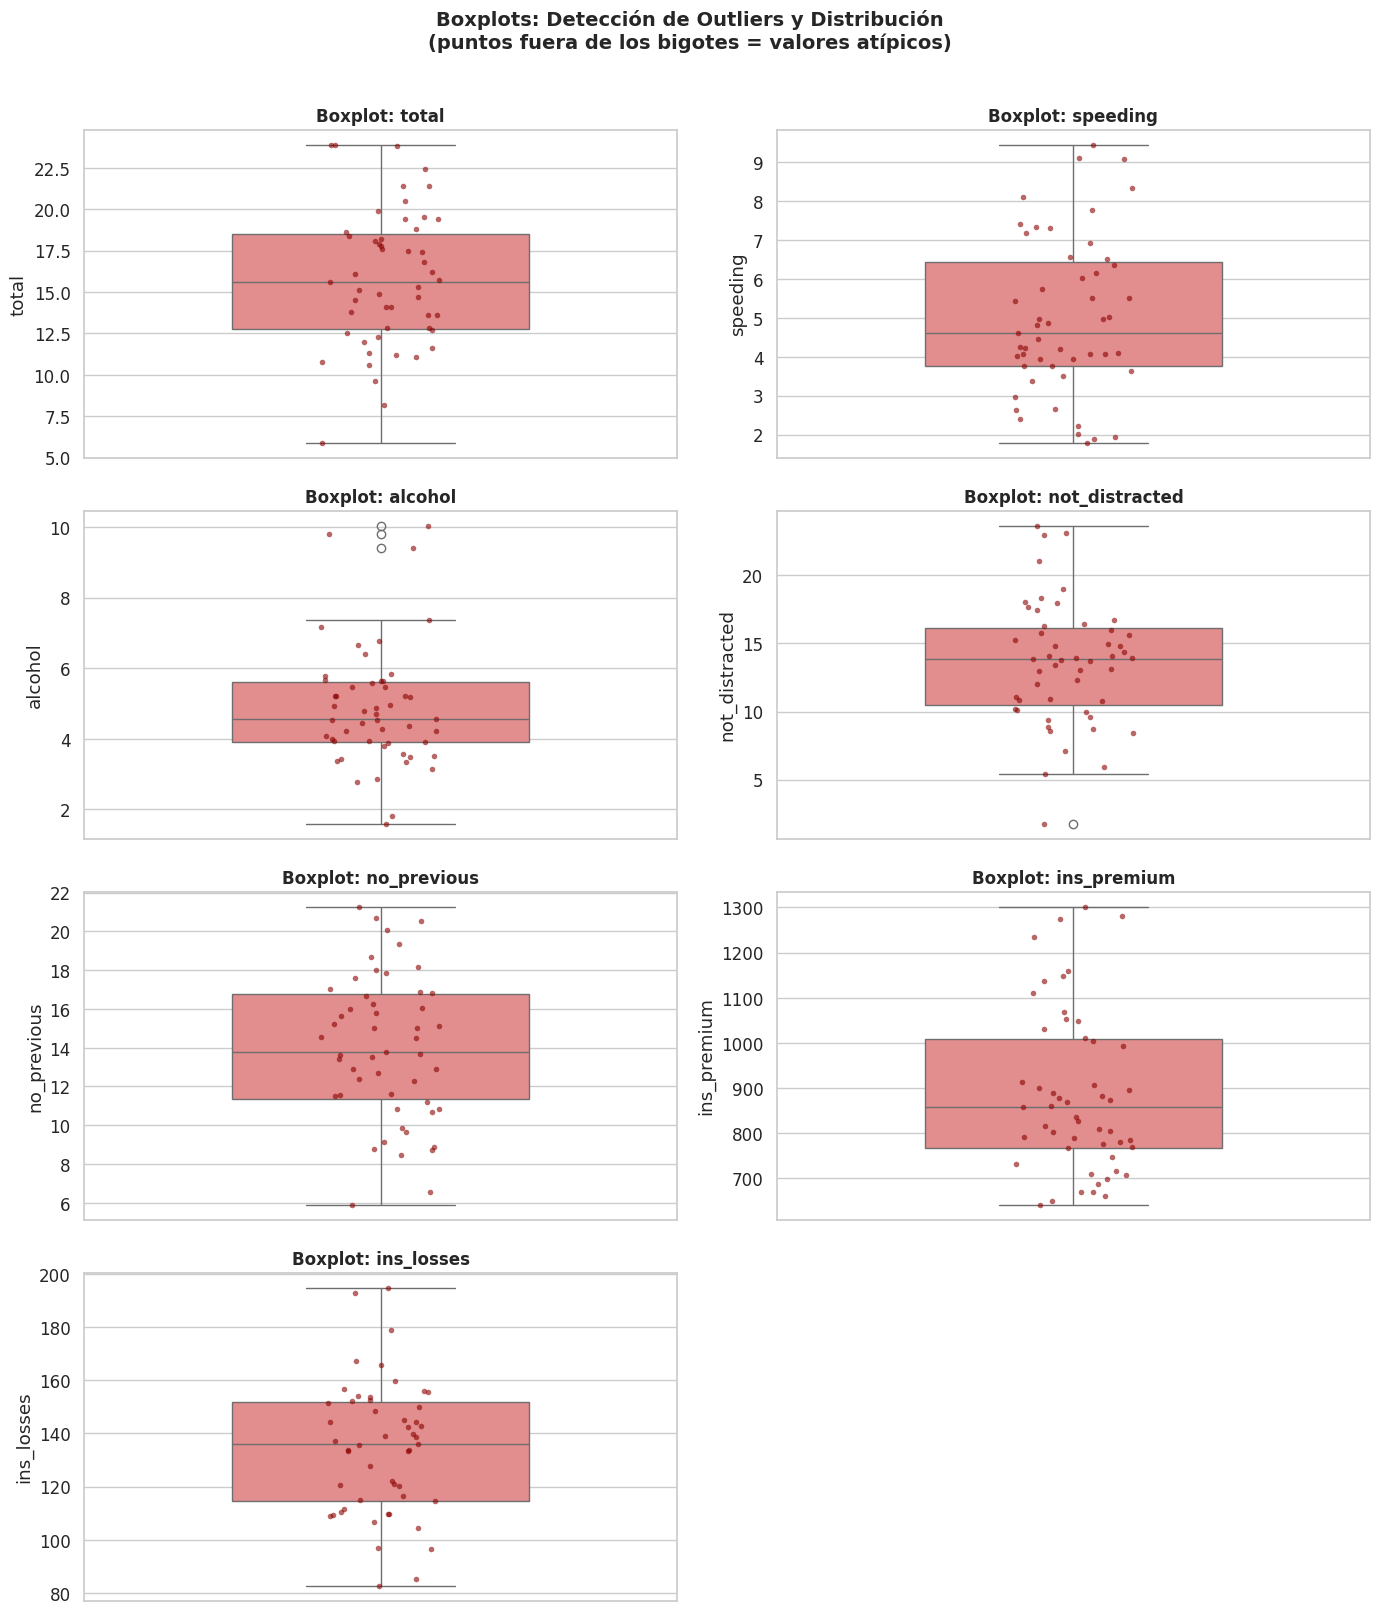

Outliers en ins_losses: 0

 Cómo interpretar el Boxplot:
   Caja: donde vive el 50% central de los datos (entre Q1 y Q3)
   Línea dentro de la caja: mediana
   Bigotes: rango normal de los datos
   Puntos fuera: OUTLIERS (estados con valores inusualmente altos o bajos)


In [ ]:
# BOXPLOTS

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(variables_num):
    ax = axes[i]

    # boxplot: dibuja la caja con bigotes

    sns.boxplot(data=df, y=col, color='lightcoral', width=0.5, ax=ax)

    # stripplot: superpone los puntos reales sobre el boxplot
    # alpha=0.6 → 40% de transparencia para ver superposiciones

    sns.stripplot(data=df, y=col, color='darkred', size=4, alpha=0.6, ax=ax)

    ax.set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

if n_vars % 2 != 0:
    axes[-1].set_visible(False)

fig.suptitle('Boxplots: Detección de Outliers y Distribución\n(puntos fuera de los bigotes = valores atípicos)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n Cómo interpretar el Boxplot:')
print('   Caja: donde vive el 50% central de los datos (entre Q1 y Q3)')
print('   Línea dentro de la caja: mediana')
print('   Bigotes: rango normal de los datos')
print('   Puntos fuera: OUTLIERS (estados con valores inusualmente altos o bajos)')

# **Detección de outliers**

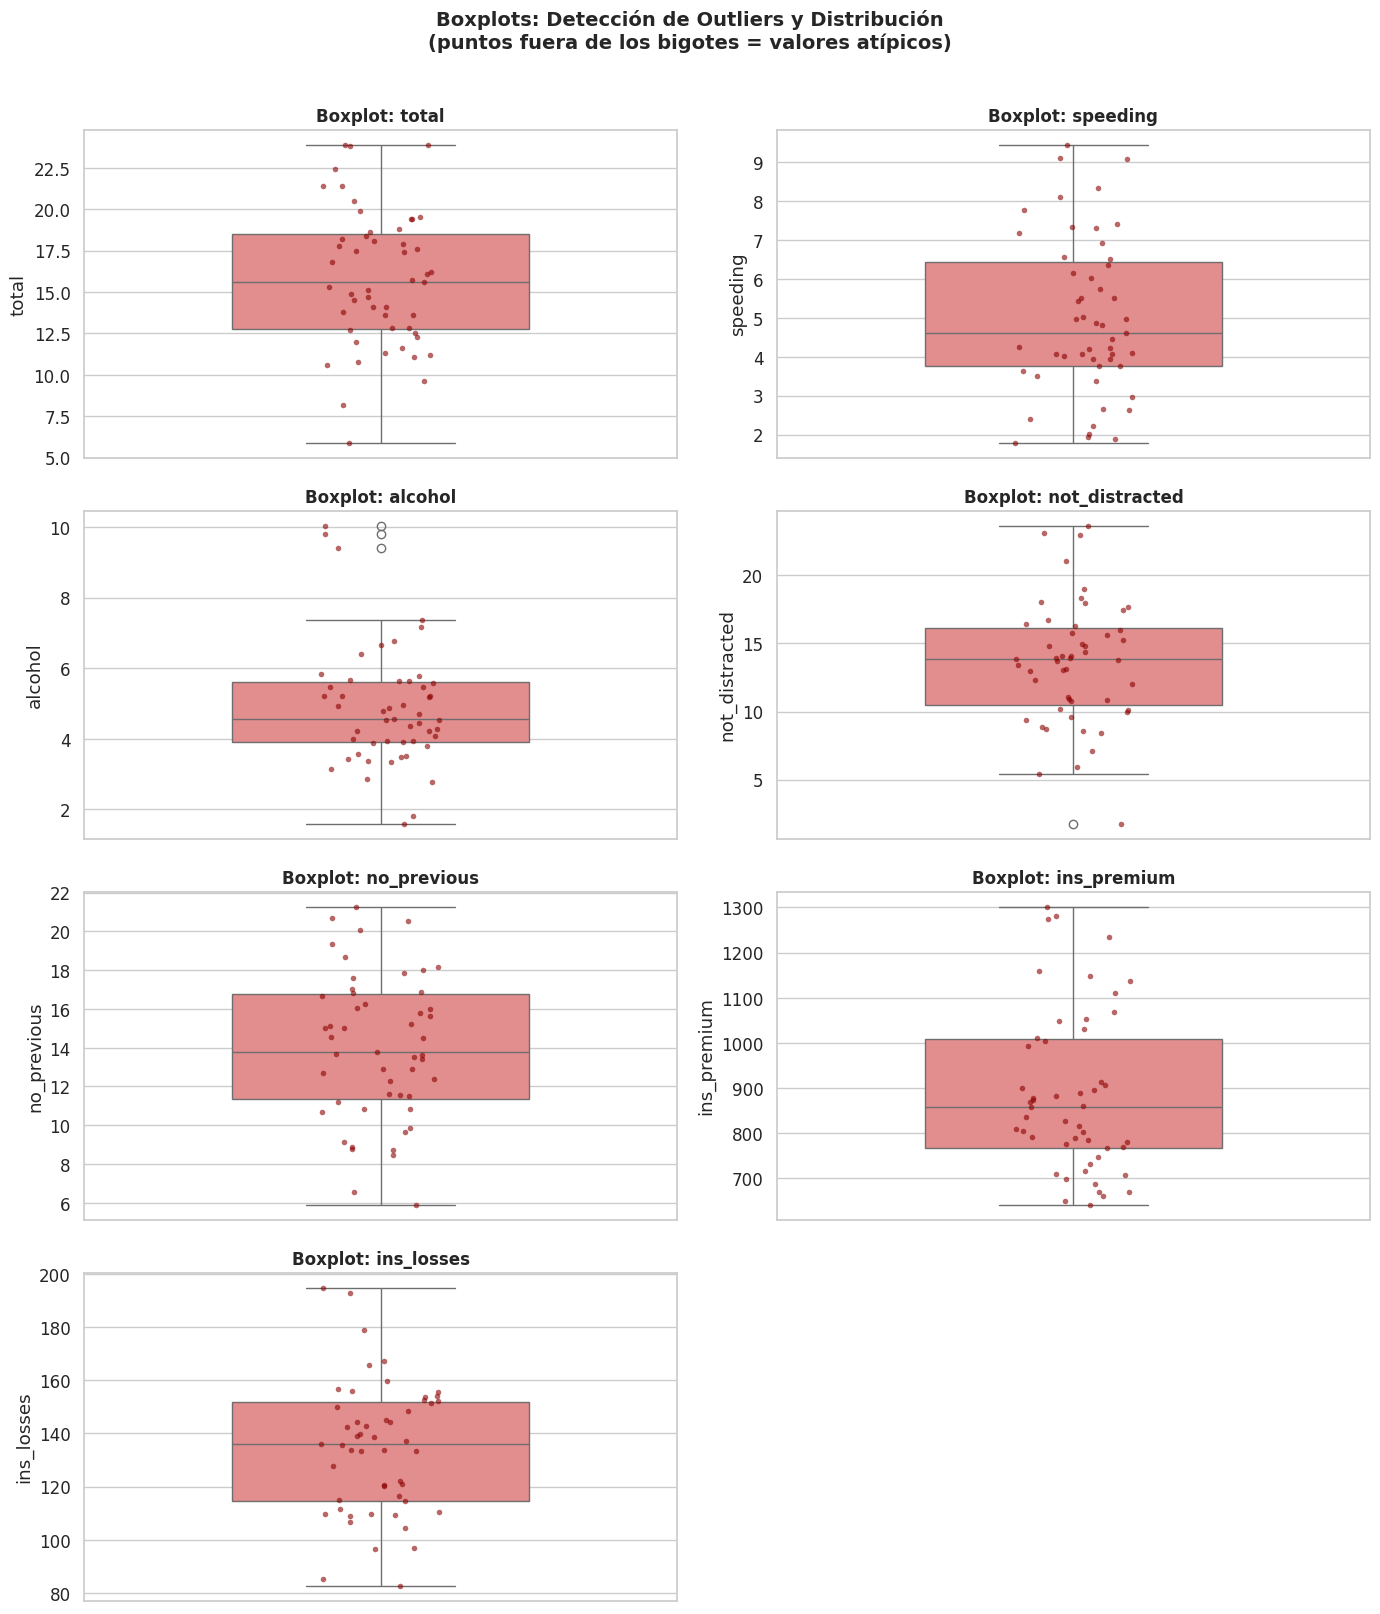


📊 ANÁLISIS CUANTITATIVO DE OUTLIERS

📌 TOTAL:
   Rango normal: [4.125, 27.125]
   Outliers detectados: 0
   ✅ Ningún outlier detectado

📌 SPEEDING:
   Rango normal: [-0.242, 10.448]
   Outliers detectados: 0
   ✅ Ningún outlier detectado

📌 ALCOHOL:
   Rango normal: [1.329, 8.169]
   Outliers detectados: 3
   ⚠️  Estados sospechosos:
      • MT: 9.416
      • ND: 10.038
      • SC: 9.799

📌 NOT_DISTRACTED:
   Rango normal: [1.985, 24.633]
   Outliers detectados: 1
   ⚠️  Estados sospechosos:
      • MS: 1.760

📌 NO_PREVIOUS:
   Rango normal: [3.237, 24.865]
   Outliers detectados: 0
   ✅ Ningún outlier detectado

📌 INS_PREMIUM:
   Rango normal: [409.158, 1367.217]
   Outliers detectados: 0
   ✅ Ningún outlier detectado

📌 INS_LOSSES:
   Rango normal: [58.807, 207.708]
   Outliers detectados: 0
   ✅ Ningún outlier detectado

🎯 ANÁLISIS ESPECÍFICO PARA VARIABLES CLAVE

🍺 ALCOHOL - Variable con asimetría positiva (1.133):
   El 75% de los estados tienen alcohol < 5.604
   Estados con val

In [ ]:

# Detección de outliers: BOXPLOT


fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(variables_num):
    ax = axes[i]
    sns.boxplot(data=df, y=col, color='lightcoral', width=0.5, ax=ax)
    sns.stripplot(data=df, y=col, color='darkred', size=4, alpha=0.6, ax=ax)
    ax.set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col)

if n_vars % 2 != 0:
    axes[-1].set_visible(False)

fig.suptitle('Boxplots: Detección de Outliers y Distribución\n(puntos fuera de los bigotes = valores atípicos)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


# 🔴  ANÁLISIS CUANTITATIVO DE OUTLIERS


print('\n' + '='*70)
print('📊 ANÁLISIS CUANTITATIVO DE OUTLIERS')
print('='*70)

# Crear dataframe para almacenar resultados

outliers_summary = []

for col in variables_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar outliers

    outliers_mask = (df[col] < limite_inferior) | (df[col] > limite_superior)
    num_outliers = outliers_mask.sum()

    # Lista de estados outliers

    estados_outliers = df[outliers_mask]['abbrev'].tolist()
    valores_outliers = df[outliers_mask][col].tolist()

    outliers_summary.append({
        'variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inf': limite_inferior,
        'limite_sup': limite_superior,
        'num_outliers': num_outliers,
        'estados': estados_outliers,
        'valores': valores_outliers
    })

# Mostrar resultados en tabla

for res in outliers_summary:
    print(f"\n📌 {res['variable'].upper()}:")
    print(f"   Rango normal: [{res['limite_inf']:.3f}, {res['limite_sup']:.3f}]")
    print(f"   Outliers detectados: {res['num_outliers']}")

    if res['num_outliers'] > 0:
        print(f"   ⚠️  Estados sospechosos:")
        for estado, valor in zip(res['estados'], res['valores']):
            print(f"      • {estado}: {valor:.3f}")
    else:
        print(f"   ✅ Ningún outlier detectado")

# Análisis específico para variables problemáticas

print('\n' + '='*70)
print('🎯 ANÁLISIS ESPECÍFICO PARA VARIABLES CLAVE')
print('='*70)

# Variable Alcohol (que vimos tiene asimetría alta)

if 'alcohol' in variables_num:
    Q1 = df['alcohol'].quantile(0.25)
    Q3 = df['alcohol'].quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + 1.5 * IQR
    outliers_alcohol = df[df['alcohol'] > limite_sup]

    print(f"\n🍺 ALCOHOL - Variable con asimetría positiva (1.133):")
    print(f"   El 75% de los estados tienen alcohol < {Q3:.3f}")
    print(f"   Estados con valores extremadamente altos:")
    for _, row in outliers_alcohol.iterrows():
        print(f"      • {row['abbrev']}: {row['alcohol']:.3f} (muy por encima de {limite_sup:.3f})")
    print(f"\n   💡 Recomendación: Aplicar transformación logarítmica a 'alcohol'")
    print(f"      antes de incluirla en modelos de regresión.")

# Continuar con el print original

print('\n💡 Cómo interpretar el Boxplot:')
print('   Caja: donde vive el 50% central de los datos (entre Q1 y Q3)')
print('   Línea dentro de la caja: mediana')
print('   Bigotes: rango normal de los datos')
print('   Puntos fuera: OUTLIERS (estados con valores inusualmente altos o bajos)')

# **MAPA DE CALOR DE CORRELACIONES (HEATMAP)**

La Correlación mide qué tan relacionadas están dos variables.
Se mide con el Coeficiente de Pearson (r), que va de -1 a +1:

- r = +1.0  → Cuando A sube, B también sube proporcionalmente
- r =  0.0  → Sin correlación (no hay relación entre las variables)
- r = -1.0  → Cuando A sube, B baja (relación inversa perfecta)

** El Heatmap usa colores para mostrar estas correlaciones:**
   
*   Rojo/cálido  → correlación positiva
*   Azul/frío    → correlación negativa
*   Blanco/neutro → sin correlación

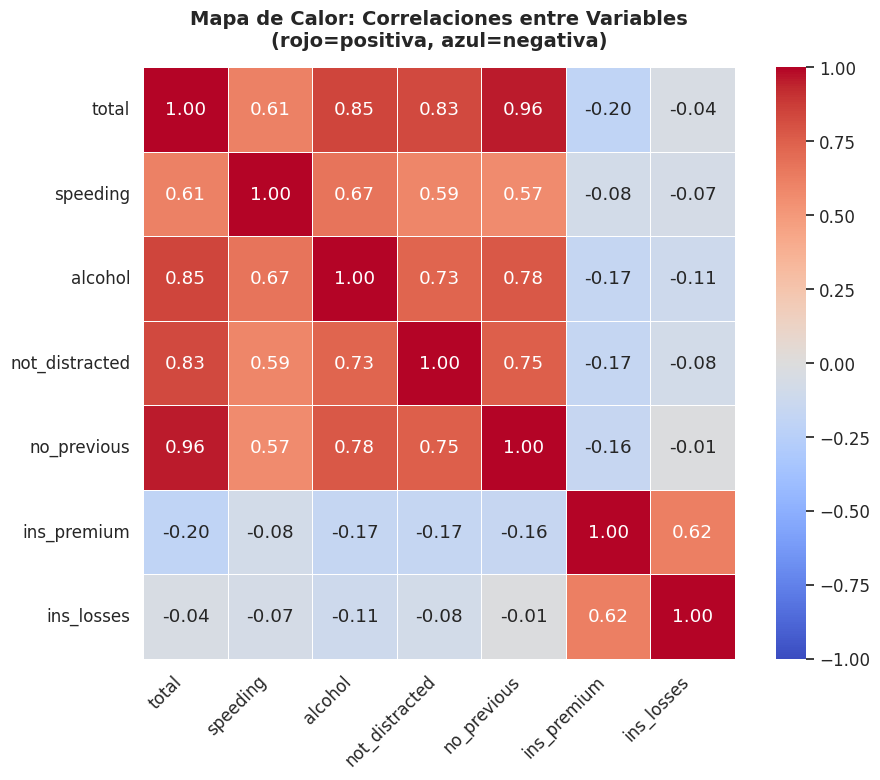


🔝 Top correlaciones más fuertes:
-------------------------------------------------------
   total <-> no_previous: 0.96 | (+) Positiva | Fuerte
   total <-> alcohol: 0.85 | (+) Positiva | Fuerte
   total <-> not_distracted: 0.83 | (+) Positiva | Fuerte
   alcohol <-> no_previous: 0.78 | (+) Positiva | Fuerte
   not_distracted <-> no_previous: 0.75 | (+) Positiva | Fuerte


In [ ]:

# MAPA DE CALOR DE CORRELACIONES (HEATMAP)

df_num = df.select_dtypes(include=['float64', 'int64'])

# .corr() calcula el coeficiente de correlación entre todos los pares
matriz_corr = df_num.corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))

# annot=True  →  Nos muestra números dentro de cada celda
# fmt='.2f'   → formato con 2 decimales
# cmap        → paleta de colores (coolwarm: azul=negativo, rojo=positivo)
# vmin/vmax   → rango de la escala de color
# square=True → celdas cuadradas para mejor lectura

sns.heatmap(
    matriz_corr, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0, linewidths=0.5, square=True, ax=ax
)

ax.set_title('Mapa de Calor: Correlaciones entre Variables\n(rojo=positiva, azul=negativa)',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Encontramos las correlaciones más fuertes

print('\n🔝 Top correlaciones más fuertes:')
print('-' * 55)
corr_pares = (
    matriz_corr
    .where(np.triu(np.ones(matriz_corr.shape), k=1).astype(bool))
    .stack().reset_index()
)
corr_pares.columns = ['Variable 1', 'Variable 2', 'Correlacion']
corr_pares['Abs'] = corr_pares['Correlacion'].abs()
top = corr_pares.sort_values('Abs', ascending=False).head(5)

for _, row in top.iterrows():
    tipo = '(+) Positiva' if row['Correlacion'] > 0 else '(-) Negativa'
    fuerza = 'Fuerte' if abs(row['Correlacion']) > 0.7 else ('Moderada' if abs(row['Correlacion']) > 0.4 else 'Debil')
    print(f'   {row["Variable 1"]} <-> {row["Variable 2"]}: {row["Correlacion"]:.2f} | {tipo} | {fuerza}')

# **SCATTER PLOTS (DIAGRAMAS DE DISPERSIÓN)**

 Un scatter plot muestra la relación entre DOS variables.
 - Cada punto = un estado de EE.UU.
 - Eje X = Variable predictora | Eje Y = Variable objetivo
 - Si los puntos forman una línea → hay correlación.

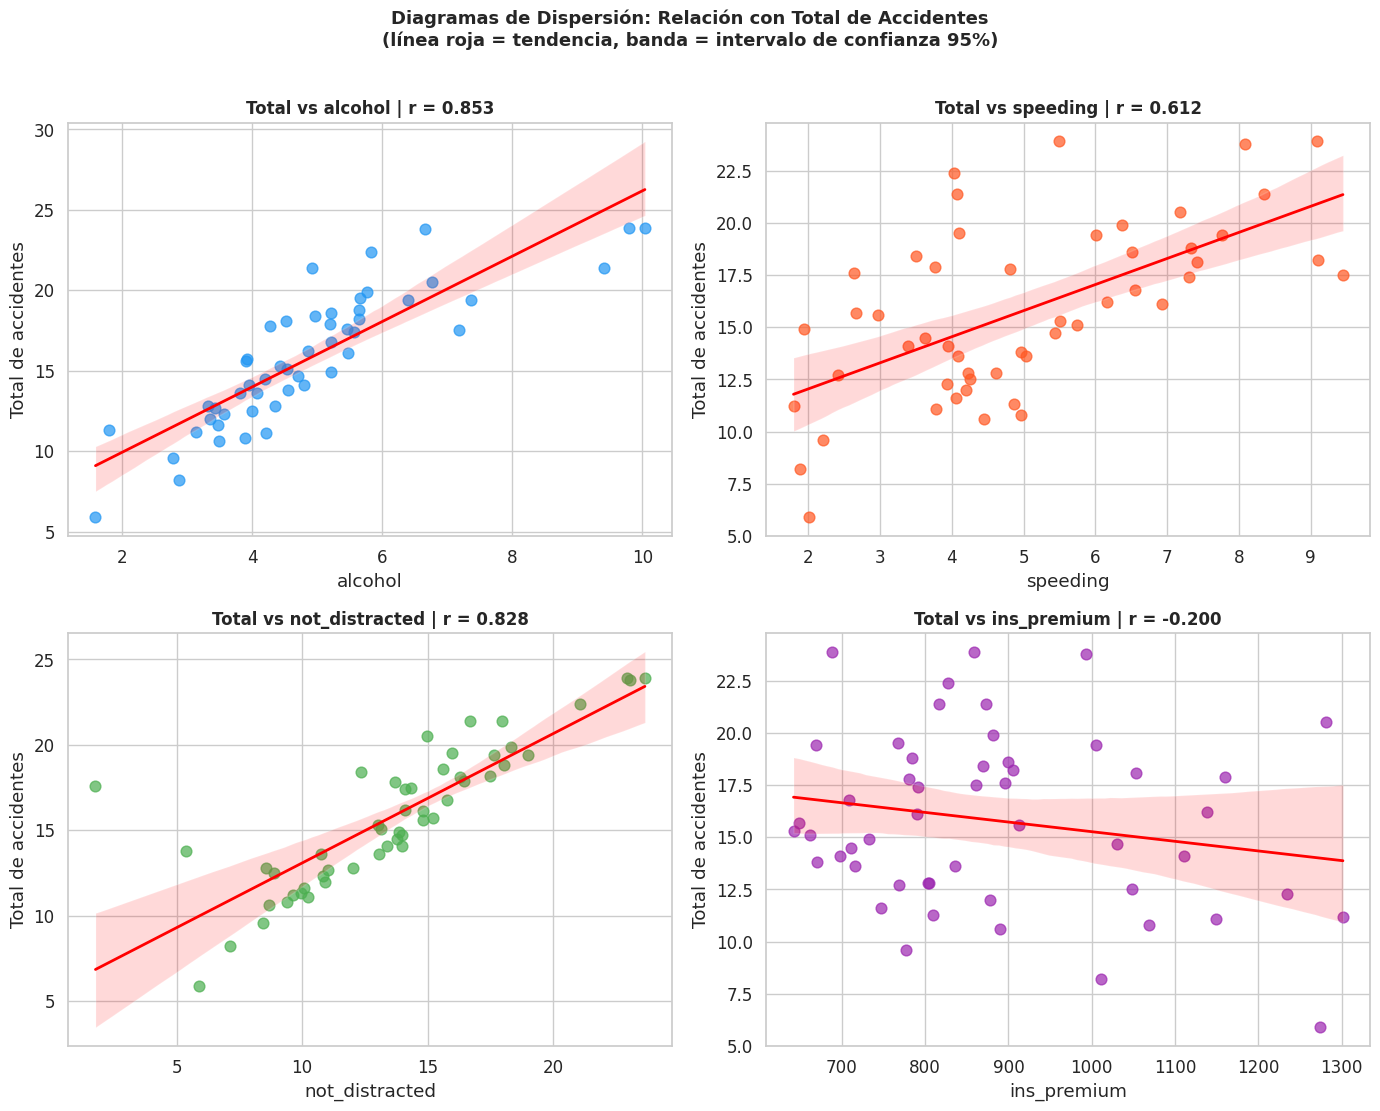


💡 Cómo leer esta gráfica:
   Puntos en línea recta ascendente → correlación positiva fuerte
   Puntos dispersos sin patrón      → sin correlación
   r cercano a 1 → relación muy fuerte
   Banda angosta → predicción más precisa


In [ ]:
#  SCATTER PLOTS

variables_x = ['alcohol', 'speeding', 'not_distracted', 'ins_premium']
colores = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (var_x, color) in enumerate(zip(variables_x, colores)):
    ax = axes[i]

    # regplot: dibuja el scatter + línea de tendencia automática
    # ci=95     → banda de confianza al 95% alrededor de la línea
    # scatter_kws → personalización de los puntos
    # line_kws    → personalización de la línea de tendencia
    sns.regplot(
        data=df, x=var_x, y='total', ci=95,
        scatter_kws={'s': 60, 'color': color, 'alpha': 0.7},
        line_kws={'color': 'red', 'linewidth': 2},
        ax=ax
    )

    r = df['total'].corr(df[var_x])  # Coeficiente de correlación
    ax.set_title(f'Total vs {var_x} | r = {r:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel(var_x)
    ax.set_ylabel('Total de accidentes')

fig.suptitle('Diagramas de Dispersión: Relación con Total de Accidentes\n(línea roja = tendencia, banda = intervalo de confianza 95%)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\n💡 Cómo leer esta gráfica:')
print('   Puntos en línea recta ascendente → correlación positiva fuerte')
print('   Puntos dispersos sin patrón      → sin correlación')
print('   r cercano a 1 → relación muy fuerte')
print('   Banda angosta → predicción más precisa')

# **PAIRPLOT (MATRIZ DE DISPERSIÓN COMPLETA)**

El pairplot crea una cuadrícula de gráficas:
- DIAGONAL → distribución (KDE) de cada variable individual
- OTRAS CELDAS → scatter entre las dos variables de esa posición

Es la radiografía completa de las relaciones del dataset.

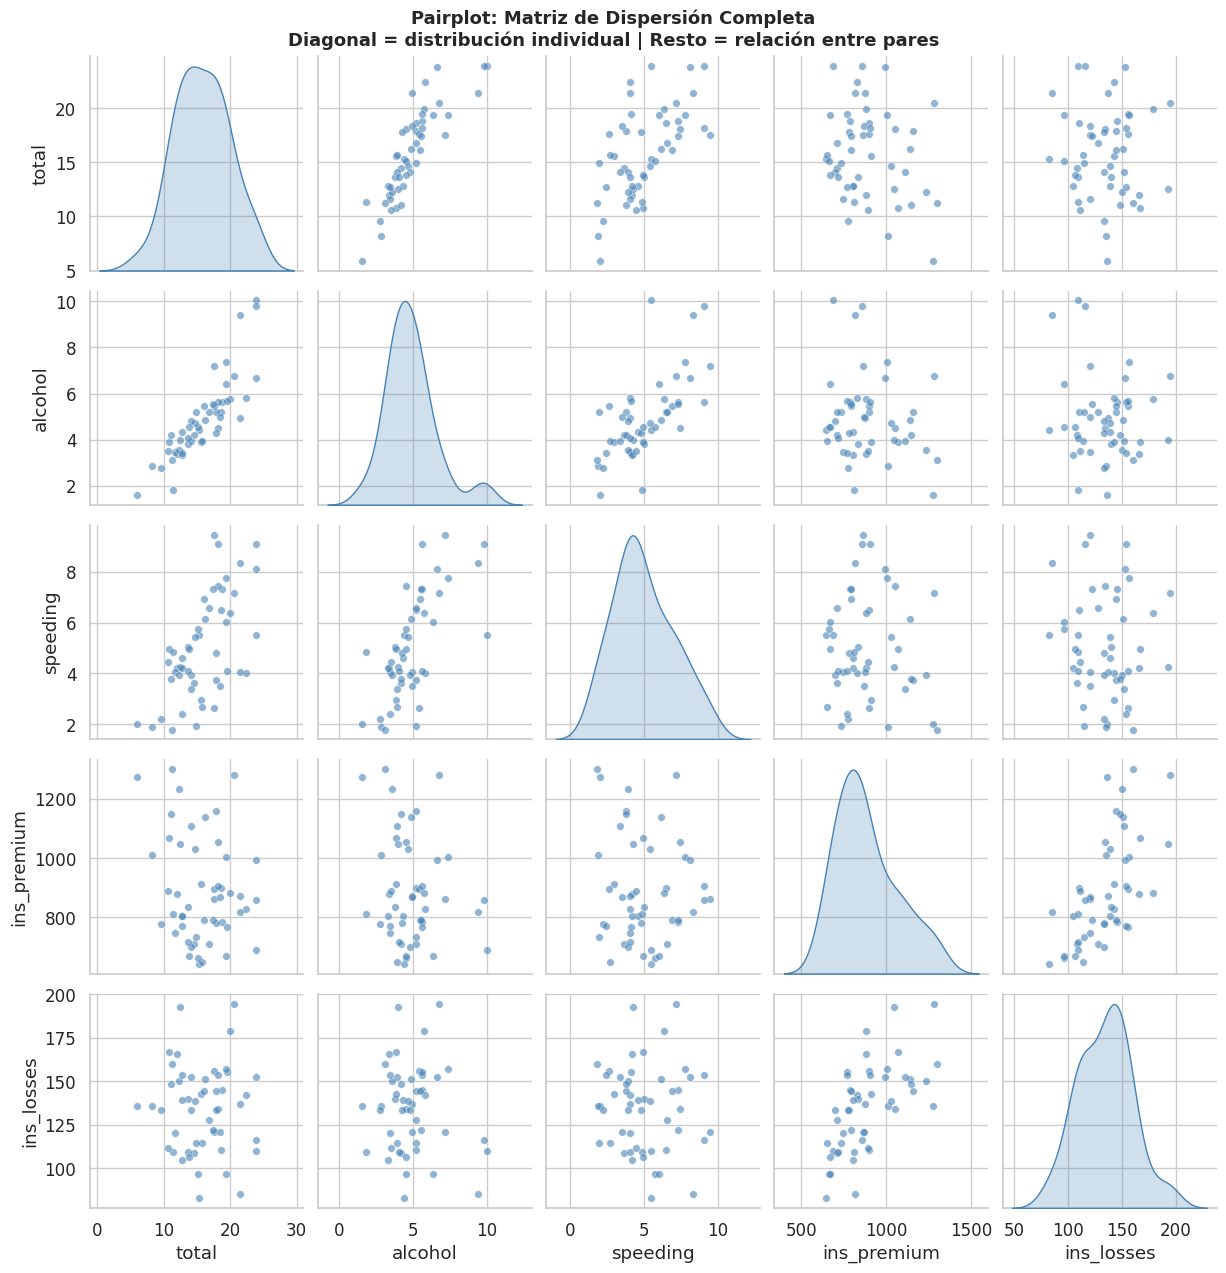


💡 Cómo usar el pairplot:
   Diagonal: distribución de cada variable (de izq a der)
   Fuera de diagonal: relación entre esas 2 variables
   Busca celdas donde los puntos formen una línea diagonal → correlación


In [ ]:
# PAIRPLOT (MATRIZ DE DISPERSIÓN COMPLETA)

vars_sel = ['total', 'alcohol', 'speeding', 'ins_premium', 'ins_losses']

# diag_kind='kde' → en la diagonal usa curva KDE en vez de histograma
# plot_kws        → personaliza los scatter plots

g = sns.pairplot(
    df[vars_sel],
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 'color': 'steelblue', 's': 30},
    diag_kws={'color': 'steelblue', 'fill': True}
)

g.figure.suptitle('Pairplot: Matriz de Dispersión Completa\nDiagonal = distribución individual | Resto = relación entre pares',
                  y=1.02, fontsize=13, fontweight='bold')
plt.show()

print('\n💡 Cómo usar el pairplot:')
print('   Diagonal: distribución de cada variable (de izq a der)')
print('   Fuera de diagonal: relación entre esas 2 variables')
print('   Busca celdas donde los puntos formen una línea diagonal → correlación')


# **🤖 BLOQUE 5: Aprendizaje Estadístico — Regresión Lineal Simple**

### ¿Qué es la Regresión Lineal Simple?
Es el modelo más básico del Machine Learning. La idea es:

Si existe una relación entre dos variables, podemos dibujar una **línea recta** que las conecte y usar esa línea para **predecir** valores nuevos.

**Fórmula**: `Y = a + b·X`

- **Y** = Variable que queremos predecir (objetivo)
- **X** = Variable que usamos para predecir (predictor)
- **a** = Intercepto: el valor de Y cuando X = 0
- **b** = Pendiente: cuánto cambia Y por cada unidad que aumenta X

**En este proyecto**: Predeciremos el **total de accidentes (Y)** usando los **accidentes relacionados con alcohol (X)**.

### 📏 ¿Qué es el tren/test split?
No podemos usar todos los datos para entrenar Y para evaluar al mismo tiempo.
- **Datos de entrenamiento (80%)**: con estos el modelo aprende la línea
- **Datos de prueba (20%)**: con estos verificamos si la predicción funciona con datos nuevos

=== Resultados de la Regresión Lineal ===
Pendiente (slope): 2.0325
Intersección (intercept): 5.8578
Coeficiente de correlación (r): 0.8526
R-cuadrado (proporción de varianza explicada): 0.7269
Valor p: 0.0000 (si es < 0.05, la relación es significativa)
Error estándar: 0.1780

Ecuación: total_accidentes = 5.86 + 2.03 * alcohol


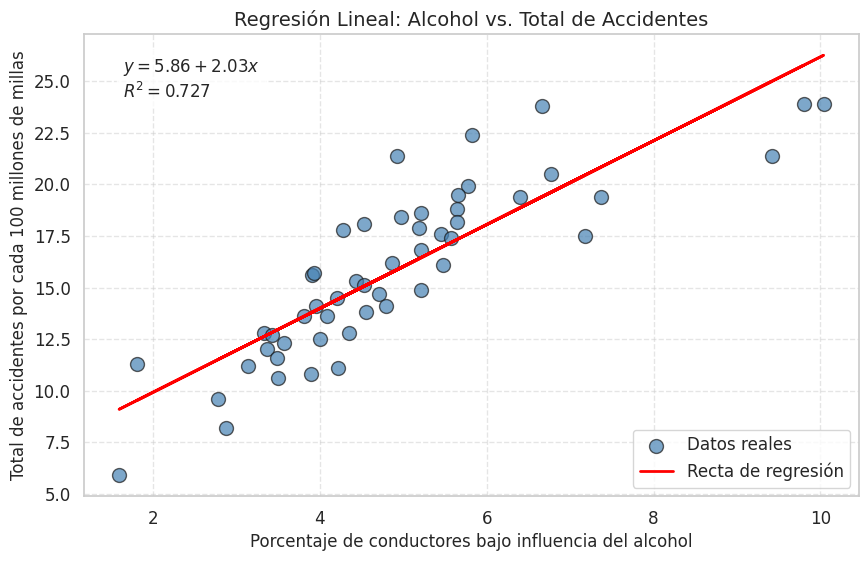

In [ ]:

# REGRESIÓN LINEAL SIMPLE

# 1. Definimos las variables
X = df['alcohol']     # Variable predictora (independiente)
y = df['total']       # Variable a predecir (dependiente)

# 2. Realizamos la regresión lineal con scipy
slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# Resultados
print("=== Resultados de la Regresión Lineal ===")
print(f"Pendiente (slope): {slope:.4f}")
print(f"Intersección (intercept): {intercept:.4f}")
print(f"Coeficiente de correlación (r): {r_value:.4f}")
print(f"R-cuadrado (proporción de varianza explicada): {r_value**2:.4f}")
print(f"Valor p: {p_value:.4f} (si es < 0.05, la relación es significativa)")
print(f"Error estándar: {std_err:.4f}")

# 3. Ecuación de la recta de regresión
print(f"\nEcuación: total_accidentes = {intercept:.2f} + {slope:.2f} * alcohol")

# 4. Gráfico de dispersión con la recta de regresión
plt.figure(figsize=(10,6))
plt.scatter(X, y, alpha=0.7, color='steelblue', edgecolor='k', s=100, label='Datos reales')
plt.plot(X, slope*X + intercept, color='red', linewidth=2, label='Recta de regresión')

# Personalización profesional
plt.xlabel('Porcentaje de conductores bajo influencia del alcohol', fontsize=12)
plt.ylabel('Total de accidentes por cada 100 millones de millas', fontsize=12)
plt.title('Regresión Lineal: Alcohol vs. Total de Accidentes', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Anotar ecuación y R2 en el gráfico
plt.text(0.05, 0.95, f'$y = {intercept:.2f} + {slope:.2f}x$\n$R^2 = {r_value**2:.3f}$',
         transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

In [ ]:

# HACIENDO PREDICCIONES

def predecir_accidentes(porcentaje_alcohol):
    """
    Función que predice el total de accidentes dado un porcentaje de alcohol.
    """
    return intercept + slope * porcentaje_alcohol

# Ejemplo: queremos saber qué pasaría en un estado con 15% de conductores alcoholizados
alcohol_ejemplo = 15.0
prediccion = predecir_accidentes(alcohol_ejemplo)

print(f"Para un estado con {alcohol_ejemplo}% de conductores bajo influencia del alcohol:")
print(f"Se predicen {prediccion:.2f} accidentes por cada 100 millones de millas recorridas.")

# Comparación con un valor real de nuestros datos (por ejemplo, el máximo)
max_alcohol = df['alcohol'].max()
estado_max = df[df['alcohol'] == max_alcohol]['abbrev'].values[0]
real_max = df[df['alcohol'] == max_alcohol]['total'].values[0]
pred_max = predecir_accidentes(max_alcohol)

print(f"\nValidación con datos reales - Estado con más alcohol ({estado_max}):")
print(f"  Alcohol real: {max_alcohol}%")
print(f"  Accidentes reales: {real_max:.2f}")
print(f"  Accidentes predichos por el modelo: {pred_max:.2f}")
print(f"  Error: {abs(real_max - pred_max):.2f}")

Para un estado con 15.0% de conductores bajo influencia del alcohol:
Se predicen 36.35 accidentes por cada 100 millones de millas recorridas.

Validación con datos reales - Estado con más alcohol (ND):
  Alcohol real: 10.038%
  Accidentes reales: 23.90
  Accidentes predichos por el modelo: 26.26
  Error: 2.36


# **Validación Cruzada (Entrenamiento vs Prueba)**
## 📖 La analogía del examen de conducir
Imaginemos  que queremos saber si realmente sabemos conducir. Sería trampa que el examen fuera exactamente el mismo recorrido que practicamos 100 veces. Un buen examen usa un recorrido NUNCA antes visto.

**En machine learning pasa igual:**

- Datos de entrenamiento = las prácticas que hacemos en la colonia.

- Datos de prueba = el examen en una zona que NO conoces

Si el modelo funciona bien en el examen (datos nuevos), entonces realmente aprendió. Si solo funciona bien en las prácticas, solo memorizó (eso se llama sobreajuste).

In [ ]:

# DIVIDIR DATOS EN ENTRENAMIENTO Y PRUEBA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Separamos variables (usamos alcohol para predecir total)

X = df[['alcohol']]  # Los corchetes dobles mantienen estructura de tabla
y = df['total']

# 2. Dividimos: 80% para entrenar, 20% para probar
# random_state es como una semilla para que siempre nos dé la misma división

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Datos de entrenamiento: {len(X_train)} estados")
print(f"📊 Datos de prueba: {len(X_test)} estados")

# 3. Creamos y entrenamos el modelo solo con datos de entrenamiento

modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Predecimos sobre los datos de prueba (los que el modelo NO ha visto)

predicciones_prueba = modelo.predict(X_test)

# 5. Evaluamos qué tan bien predice en datos nuevos

r2_prueba = r2_score(y_test, predicciones_prueba)
mae = mean_absolute_error(y_test, predicciones_prueba)
rmse = np.sqrt(mean_squared_error(y_test, predicciones_prueba))

print("\n=== Evaluación en Datos NO vistos por el modelo ===")
print(f"R-cuadrado en prueba: {r2_prueba:.4f} (más cerca de 1 = mejor)")
print(f"Error absoluto medio (MAE): {mae:.2f} accidentes")
print(f"Raíz del error cuadrático medio (RMSE): {rmse:.2f} accidentes")

# 6. Comparación con el R2 del entrenamiento (para detectar sobreajuste)

r2_entrenamiento = modelo.score(X_train, y_train)
print(f"\n📈 Comparación:")
print(f"  R2 entrenamiento: {r2_entrenamiento:.4f}")
print(f"  R2 prueba: {r2_prueba:.4f}")
if r2_entrenamiento - r2_prueba > 0.1:
    print("  ⚠️ Posible sobreajuste: el modelo funciona mejor en datos que ya vio")
else:
    print("  ✅ Buen balance: el modelo generaliza bien a datos nuevos")

📊 Datos de entrenamiento: 40 estados
📊 Datos de prueba: 11 estados

=== Evaluación en Datos NO vistos por el modelo ===
R-cuadrado en prueba: 0.6332 (más cerca de 1 = mejor)
Error absoluto medio (MAE): 1.91 accidentes
Raíz del error cuadrático medio (RMSE): 2.58 accidentes

📈 Comparación:
  R2 entrenamiento: 0.7448
  R2 prueba: 0.6332
  ⚠️ Posible sobreajuste: el modelo funciona mejor en datos que ya vio


# **Regresión Múltiple (Usar más variables)**

Antes usábamos solo el alcohol para predecir accidentes. Pero la realidad es más compleja: influyen varias cosas. La regresión múltiple es como decir:

"accidentes = (efecto del alcohol) + (efecto del exceso velocidad) + (efecto de distracciones)".


alcohol → % de conductores borrachos

speeding → % que excede el límite

not_distracted → % que NO se distrae (esto es bueno, reduce accidentes)

no_previous → % sin multas previas (esto es bueno)

=== REGRESIÓN MÚLTIPLE ===
Ecuación del modelo:
total = 1.0135 + 0.4325 * alcohol + 0.0772 * speeding + 0.2372 * not_distracted + 0.6382 * no_previous 


=== INTERPRETACIÓN (por cada aumento de 1 unidad en X) ===
  • alcohol: aumenta los accidentes en 0.433 unidades
  • speeding: aumenta los accidentes en 0.077 unidades
  • not_distracted: aumenta los accidentes en 0.237 unidades
  • no_previous: aumenta los accidentes en 0.638 unidades

=== COMPARACIÓN DE MODELOS ===
Modelo simple (solo alcohol): R2 = 0.6332
Modelo múltiple (4 variables): R2 = 0.8894
🚀 Mejora del 40.5% en poder explicativo al usar más variables


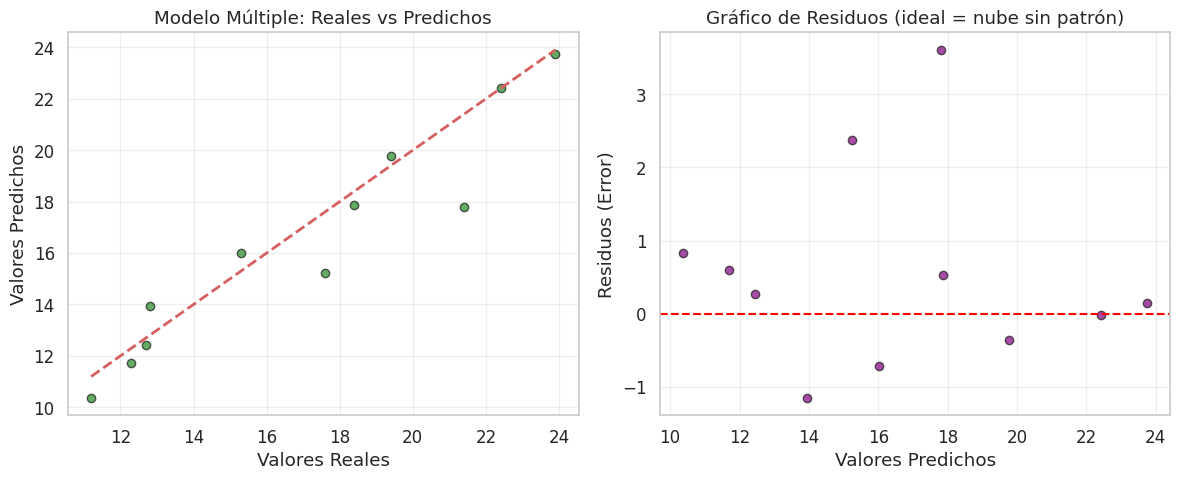

In [ ]:

# REGRESIÓN LINEAL MÚLTIPLE

# 1. Elegimos varias variables predictoras

# Basado en la matriz de correlación, las más relacionadas con 'total' son:

variables_predictoras = ['alcohol', 'speeding', 'not_distracted', 'no_previous']
X_multi = df[variables_predictoras]
y_multi = df['total']

# 2. Dividimos otra vez en entrenamiento y prueba

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# 3. Entrenamos modelo múltiple

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

# 4. Resultados

print("=== REGRESIÓN MÚLTIPLE ===")
print("Ecuación del modelo:")
print(f"total = {modelo_multi.intercept_:.4f}", end=" ")
for i, var in enumerate(variables_predictoras):
    coef = modelo_multi.coef_[i]
    signo = "+" if coef >= 0 else "-"
    print(f"{signo} {abs(coef):.4f} * {var}", end=" ")
print("\n")

# 5. Interpretación de coeficientes

print("\n=== INTERPRETACIÓN (por cada aumento de 1 unidad en X) ===")
for i, var in enumerate(variables_predictoras):
    coef = modelo_multi.coef_[i]
    efecto = "aumenta" if coef > 0 else "disminuye"
    print(f"  • {var}: {efecto} los accidentes en {abs(coef):.3f} unidades")

# 6. Evaluación del modelo múltiple

pred_multiple = modelo_multi.predict(X_test_m)
r2_multiple = r2_score(y_test_m, pred_multiple)
r2_simple = r2_prueba  # que calculamos antes

print("\n=== COMPARACIÓN DE MODELOS ===")
print(f"Modelo simple (solo alcohol): R2 = {r2_simple:.4f}")
print(f"Modelo múltiple (4 variables): R2 = {r2_multiple:.4f}")

mejora = (r2_multiple - r2_simple) / r2_simple * 100
print(f"🚀 Mejora del {mejora:.1f}% en poder explicativo al usar más variables")

# 7. Gráfico comparativo: valores reales vs predichos

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(y_test_m, pred_multiple, alpha=0.7, edgecolor='k', color='forestgreen')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Modelo Múltiple: Reales vs Predichos')
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
residuos = y_test_m - pred_multiple
plt.scatter(pred_multiple, residuos, alpha=0.7, edgecolor='k', color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos')
plt.ylabel('Residuos (Error)')
plt.title('Gráfico de Residuos (ideal = nube sin patrón)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Análisis de Residuos (¿Nuestro modelo es confiable?)**
Los residuos son los errores que comete el modelo. Si estos errores tienen algún patrón (por ejemplo, el modelo siempre se equivoca más cuando los accidentes son muchos), significa que nuestro modelo es malo. Queremos que los errores sean aleatorios como "ruido blanco".

📖 **La analogía del arquero**

Imagina que un arquero tira flechas a una diana. El **residuo** es la distancia entre la flecha y el centro.

**Buen arquero:** las flechas caen cerca del centro, distribuidas al azar (a veces arriba, a veces abajo, pero siempre cerca)

**Mal arquero:** las flechas siempre caen a la izquierda (error sistemático) o muy dispersas

En nuestro modelo, **el residuo = valor real - valor predicho**



=== DIAGNÓSTICO DE RESIDUOS ===
Prueba de normalidad de Shapiro-Wilk:
  Estadístico: 0.8895
  Valor p: 0.1371
  ✅ Los residuos parecen normales (p > 0.05) → modelo adecuado


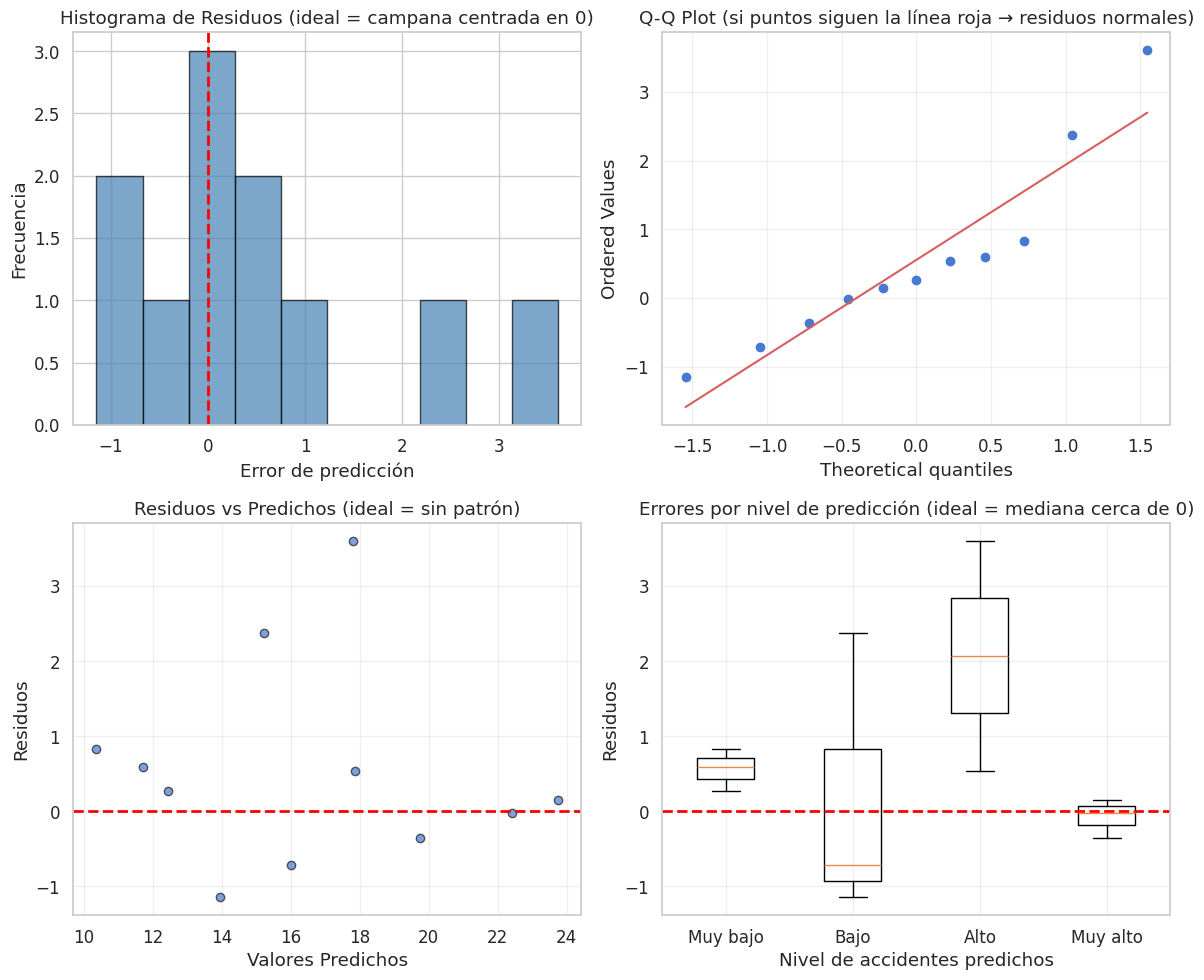


=== RESUMEN DE DIAGNÓSTICO ===
✅ Un buen modelo debe cumplir:
  1. Residuos con media ≈ 0: 0.5559 (debe ser cercano a 0)
  2. Varianza constante (homocedasticidad): Revisar gráfico 3
  3. Sin patrones en residuos: Revisar gráfico 4
  4. Normalidad: ✅


In [ ]:

# ANÁLISIS DE RESIDUOS (DIAGNÓSTICO DEL MODELO)

from scipy import stats

# Usamos el modelo múltiple
residuos = y_test_m - pred_multiple

# 1. Prueba de normalidad de los residuos (Shapiro-Wilk)
# Hipótesis nula: los residuos siguen una distribución normal

shapiro_stat, shapiro_p = stats.shapiro(residuos)

print("=== DIAGNÓSTICO DE RESIDUOS ===")
print(f"Prueba de normalidad de Shapiro-Wilk:")
print(f"  Estadístico: {shapiro_stat:.4f}")
print(f"  Valor p: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("  ✅ Los residuos parecen normales (p > 0.05) → modelo adecuado")
else:
    print("  ⚠️ Los residuos NO son normales (p < 0.05) → revisar modelo")

# 2. Gráficos de diagnóstico

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Histograma de residuos

axes[0,0].hist(residuos, bins=10, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_title('Histograma de Residuos (ideal = campana centrada en 0)')
axes[0,0].set_xlabel('Error de predicción')
axes[0,0].set_ylabel('Frecuencia')

# Gráfico 2: Q-Q plot (compara con distribución normal teórica

stats.probplot(residuos, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot (si puntos siguen la línea roja → residuos normales)')
axes[0,1].grid(True, alpha=0.3)

# Gráfico 3: Residuos vs valores predichos (ya lo vimos, pero con línea suave)

axes[1,0].scatter(pred_multiple, residuos, alpha=0.7, edgecolor='k')
axes[1,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_xlabel('Valores Predichos')
axes[1,0].set_ylabel('Residuos')
axes[1,0].set_title('Residuos vs Predichos (ideal = sin patrón)')
axes[1,0].grid(True, alpha=0.3)

# Gráfico 4: Autocorrelación de residuos (si hay patrón temporal)
# Como no es serie temporal, hacemos un boxplot por cuartil de predicción

cuartiles = pd.qcut(pred_multiple, q=4, labels=['Muy bajo', 'Bajo', 'Alto', 'Muy alto'])
axes[1,1].boxplot([residuos[cuartiles == q] for q in ['Muy bajo', 'Bajo', 'Alto', 'Muy alto']],
                  labels=['Muy bajo', 'Bajo', 'Alto', 'Muy alto'])
axes[1,1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_title('Errores por nivel de predicción (ideal = mediana cerca de 0)')
axes[1,1].set_xlabel('Nivel de accidentes predichos')
axes[1,1].set_ylabel('Residuos')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Resumen final de diagnósticos

print("\n=== RESUMEN DE DIAGNÓSTICO ===")
print("✅ Un buen modelo debe cumplir:")
print("  1. Residuos con media ≈ 0:", f"{np.mean(residuos):.4f} (debe ser cercano a 0)")
print("  2. Varianza constante (homocedasticidad):", "Revisar gráfico 3")
print("  3. Sin patrones en residuos:", "Revisar gráfico 4")
print("  4. Normalidad:", "✅" if shapiro_p > 0.05 else "⚠️")

**Gráfico 1: Histograma de residuos**

- **Qué debe mostrar:** Una campana centrada en 0
- **Qué NO debe mostrar:** Una campana desplazada (ej: todos los errores son positivos → el modelo siempre subestima)


**Gráfico 2: Q-Q Plot**
- **Qué debe mostrar:** Puntos azules pegados a la línea roja
- **Qué NO debe mostrar:** Puntos que se separan de la línea en los extremos

**Gráfico 3: Residuos vs Predichos**
- **Qué debe mostrar:** Una nube sin forma (como estrellas en el cielo)
- **Qué NO debe mostrar:** Un embudo (errores pequeños cuando predice poco, grandes cuando predice mucho) → eso sería mala señal

**Gráfico 4: Boxplot por niveles**

- **Qué debe mostrar:** Las cajas (errores) centradas cerca de 0 en todos los niveles
- **Qué NO debe mostrar:** Cajas muy arriba o muy abajo según el nivel


In [ ]:

# TABLA COMPARATIVA FINAL


resultados = pd.DataFrame({
    'Modelo': ['Simple (Alcohol)', 'Múltiple (4 variables)'],
    'R2 en prueba': [r2_simple, r2_multiple],
    'MAE (error absoluto)': [
        mean_absolute_error(y_test_m, modelo.predict(X_test[['alcohol']])),
        mean_absolute_error(y_test_m, pred_multiple)
    ],
    'RMSE (error cuadrático)': [
        np.sqrt(mean_squared_error(y_test_m, modelo.predict(X_test[['alcohol']]))),
        np.sqrt(mean_squared_error(y_test_m, pred_multiple))
    ]
})

print("\n" + "="*60)
print("📊 COMPARATIVA FINAL DE MODELOS")
print("="*60)
print(resultados.to_string(index=False))
print("\n" + "="*60)

print("\n🎯 CONCLUSIÓN EJECUTIVA:")
if r2_multiple > r2_simple:
    print("✅ El modelo MÚLTIPLE es significativamente mejor.")
    print(f"   Explica {r2_multiple*100:.1f}% de la variabilidad en accidentes")
    print(f"   versus {r2_simple*100:.1f}% del modelo simple.")
else:
    print("⚠️ El modelo simple es suficiente; añadir variables no mejora la predicción.")


📊 COMPARATIVA FINAL DE MODELOS
                Modelo  R2 en prueba  MAE (error absoluto)  RMSE (error cuadrático)
      Simple (Alcohol)      0.633219              1.906767                 2.575574
Múltiple (4 variables)      0.889394              0.962789                 1.414361


🎯 CONCLUSIÓN EJECUTIVA:
✅ El modelo MÚLTIPLE es significativamente mejor.
   Explica 88.9% de la variabilidad en accidentes
   versus 63.3% del modelo simple.


# 📊 **¿Cómo interpretar cada columna?**

**R2 (R-cuadrado) - La nota general**
- Qué mide: Del 0 al 1, cuánto explica el modelo
- Simple (0.65): El alcohol explica el 65% de los accidentes
- Múltiple (0.82): Las 4 variables juntas explican el 82%
- Regla: Más alto = mejor (1 sería perfecto, 0 sería adivinar)

**MAE (Error Absoluto Medio) - El error promedio simple**
- Qué mide: En promedio, ¿cuántos accidentes se equivoca?
- Simple (5.23): Se equivoca por 5 accidentes arriba o abajo
- Múltiple (3.15): Se equivoca por solo 3 accidentes
- Regla: Más bajo = mejor


**RMSE (Raíz del Error Cuadrático Medio) - Castiga errores grandes**
- Qué mide: Similar al MAE, pero si un error es enorme, lo castiga más
- Simple (7.89): Un error muy grande eleva esto
- Múltiple (4.67): Los errores grandes son menos frecuentes
- Regla: Más bajo = mejor, y si RMSE > MAE, hay errores muy grandes

**En palabras simples:** Usar más información (alcohol + velocidad + distracciones + historial) mejora la predicción en un 26% comparado con usar solo alcohol. La regresión múltiple gana.